# OdiaGPT — Master Notebook (Single File, Complete)
**English → Odia Neural Machine Translator | Built from scratch**

## Run order every time you open this notebook:
| Step | What | Every restart? |
|------|------|----------------|
| STEP 1 | Memory clear + imports | ✅ Yes |
| STEP 2 | Load dataset | ✅ Yes |
| STEP 3 | Load tokenizers | ✅ Yes |
| STEP 4 | Dataset class + DataLoaders | ✅ Yes |
| STEP 5 | Model architecture | ✅ Yes |
| STEP 6 | Training — skip if just evaluating | Only when training |
| STEP 7 | Load checkpoint + translate | ✅ Yes (after STEP 5) |
| STEP 8 | Evaluation + scores | After loading |
| STEP 9 | Visualizations — auto reads checkpoints | After loading |

**Checkpoints are on disk — restarting kernel never deletes them.**

## STEP 1 — Memory Clear + Imports
⚠️ Always run this first every time.

In [1]:
import os, gc, math, random, json
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch
import torch.nn as nn
import sacrebleu
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tqdm import tqdm

# Create required folders
for folder in ["./odiagpt", "./tokenizer_en", "./tokenizer_or", "./logs"]:
    os.makedirs(folder, exist_ok=True)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print("✅ STEP 1 complete.")

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB
✅ STEP 1 complete.


## STEP 2 — Load Dataset (500k)
**Do NOT change TRAIN_SIZE** — 500k is the safe max for RTX 3050 6GB.

In [2]:
print("Loading Samanantar English-Odia dataset from HuggingFace...")
raw_dataset = load_dataset("ai4bharat/samanantar", "or", split="train")
print(f"Total available: {len(raw_dataset):,} pairs")

TRAIN_SIZE, VAL_SIZE = 500000, 3000
raw_train_dataset, rest = random_split(raw_dataset, [TRAIN_SIZE, len(raw_dataset)-TRAIN_SIZE])
raw_val_dataset,   _    = random_split(rest, [VAL_SIZE, len(rest)-VAL_SIZE])

print(f"Train : {len(raw_train_dataset):,}")
print(f"Val   : {len(raw_val_dataset):,}")
gc.collect()
print("✅ STEP 2 complete.")

Loading Samanantar English-Odia dataset from HuggingFace...
Total available: 998,228 pairs
Train : 500,000
Val   : 3,000
✅ STEP 2 complete.


## STEP 3 — Load Tokenizers
⚠️ Tokenizers are already trained. Load from files — never retrain.

In [3]:
tokenizer_en = Tokenizer.from_file("./tokenizer_en/tokenizer_en.json")
tokenizer_or = Tokenizer.from_file("./tokenizer_or/tokenizer_or.json")
print(f"EN vocab : {tokenizer_en.get_vocab_size()}")
print(f"OR vocab : {tokenizer_or.get_vocab_size()}")
print("✅ STEP 3 complete.")

EN vocab : 30000
OR vocab : 30000
✅ STEP 3 complete.


## STEP 4 — Dataset Class + DataLoaders

In [4]:
max_seq_len = 160

def causal_mask(size):
    mask = torch.triu(torch.ones(1, size, size), diagonal=1).type(torch.int)
    return mask == 0

class EncodeDataset(Dataset):
    def __init__(self, raw_dataset, max_seq_len):
        super().__init__()
        self.raw_dataset = raw_dataset
        self.max_seq_len = max_seq_len
        self.CLS_ID = tokenizer_or.token_to_id("[CLS]")
        self.SEP_ID = tokenizer_or.token_to_id("[SEP]")
        self.PAD_ID = tokenizer_or.token_to_id("[PAD]")
    def __len__(self): return len(self.raw_dataset)
    def __getitem__(self, idx):
        raw     = self.raw_dataset[idx]
        src_ids = tokenizer_en.encode(raw["src"]).ids[:self.max_seq_len-2]
        tgt_ids = tokenizer_or.encode(raw["tgt"]).ids[:self.max_seq_len-1]
        sp = self.max_seq_len - len(src_ids) - 2
        tp = self.max_seq_len - len(tgt_ids) - 1
        enc_in  = torch.tensor([self.CLS_ID]+src_ids+[self.SEP_ID]+[self.PAD_ID]*sp, dtype=torch.int64)
        dec_in  = torch.tensor([self.CLS_ID]+tgt_ids+[self.PAD_ID]*tp, dtype=torch.int64)
        tgt_lbl = torch.tensor(tgt_ids+[self.SEP_ID]+[self.PAD_ID]*tp, dtype=torch.int64)
        enc_mask = (enc_in != self.PAD_ID).unsqueeze(0).unsqueeze(0).int()
        dec_mask = (dec_in != self.PAD_ID).unsqueeze(0).unsqueeze(0).int() & causal_mask(self.max_seq_len)
        return {"encoder_input":enc_in,"decoder_input":dec_in,"target_label":tgt_lbl,
                "encoder_mask":enc_mask,"decoder_mask":dec_mask,
                "source_text":raw["src"],"target_text":raw["tgt"]}

train_ds = EncodeDataset(raw_train_dataset, max_seq_len)
val_ds   = EncodeDataset(raw_val_dataset,   max_seq_len)
train_dataloader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=0)
val_dataloader   = DataLoader(val_ds,   batch_size=1,  shuffle=False, num_workers=0)
print(f"Train batches : {len(train_dataloader):,}  (should be 31,250 for 500k)")
print("✅ STEP 4 complete.")

Train batches : 31,250  (should be 31,250 for 500k)
✅ STEP 4 complete.


## STEP 5 — Model Architecture
⚠️ Variable names must never change — they must match checkpoint keys exactly.

In [5]:
class EmbeddingLayer(nn.Module):
    def __init__(self, d_model, vocab_size):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.d_model)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_len, dropout_rate):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        pe  = torch.zeros(max_seq_len, d_model)
        pos = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.shape[1], :].requires_grad_(False))

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout_rate):
        super().__init__()
        assert d_model % num_heads == 0
        self.dropout = nn.Dropout(dropout_rate)
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
    def forward(self, q, k, v, mask):
        B = q.shape[0]
        Q = self.W_q(q).view(B,-1,self.num_heads,self.d_k).transpose(1,2)
        K = self.W_k(k).view(B,-1,self.num_heads,self.d_k).transpose(1,2)
        V = self.W_v(v).view(B,-1,self.num_heads,self.d_k).transpose(1,2)
        sc = (Q @ K.transpose(-2,-1)) / math.sqrt(self.d_k)
        if mask is not None: sc = sc.masked_fill(mask==0, float("-inf"))
        sc = self.dropout(sc.softmax(dim=-1))
        return self.W_o((sc @ V).transpose(1,2).contiguous().view(B,-1,self.num_heads*self.d_k))

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout_rate):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.layer_1 = nn.Linear(d_model, d_ff)
        self.layer_2 = nn.Linear(d_ff, d_model)
    def forward(self, x):
        return self.layer_2(self.dropout(torch.relu(self.layer_1(x))))

class LayerNorm(nn.Module):
    def __init__(self, d_model=512, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta  = nn.Parameter(torch.zeros(d_model))
    def forward(self, x):
        m = x.mean(dim=-1, keepdim=True)
        s = x.std(dim=-1,  keepdim=True)
        return self.gamma * (x-m)/(s+self.eps) + self.beta

class AddAndNorm(nn.Module):
    def __init__(self, d_model, dropout_rate):
        super().__init__()
        self.dropout    = nn.Dropout(dropout_rate)
        self.layer_norm = LayerNorm(d_model)
    def forward(self, x, sub):
        return x + self.dropout(sub(self.layer_norm(x)))

class EncoderBlock(nn.Module):
    def __init__(self, d_model, multihead_attention, feed_forward, dropout_rate):
        super().__init__()
        self.multihead_attention = multihead_attention
        self.feed_forward        = feed_forward
        self.addnorm_1 = AddAndNorm(d_model, dropout_rate)
        self.addnorm_2 = AddAndNorm(d_model, dropout_rate)
    def forward(self, x, mask):
        x = self.addnorm_1(x, lambda x: self.multihead_attention(x,x,x,mask))
        return self.addnorm_2(x, self.feed_forward)

class Encoder(nn.Module):
    def __init__(self, d_model, block_list):
        super().__init__()
        self.block_list = block_list
        self.layer_norm = LayerNorm(d_model)
    def forward(self, x, mask):
        for b in self.block_list: x = b(x, mask)
        return self.layer_norm(x)

class DecoderBlock(nn.Module):
    def __init__(self, d_model, masked_attn, cross_attn, feed_forward, dropout_rate):
        super().__init__()
        self.masked_attn  = masked_attn
        self.cross_attn   = cross_attn
        self.feed_forward = feed_forward
        self.addnorm_1 = AddAndNorm(d_model, dropout_rate)
        self.addnorm_2 = AddAndNorm(d_model, dropout_rate)
        self.addnorm_3 = AddAndNorm(d_model, dropout_rate)
    def forward(self, x, enc_out, enc_mask, dec_mask):
        x = self.addnorm_1(x, lambda x: self.masked_attn(x,x,x,dec_mask))
        x = self.addnorm_2(x, lambda x: self.cross_attn(x,enc_out,enc_out,enc_mask))
        return self.addnorm_3(x, self.feed_forward)

class Decoder(nn.Module):
    def __init__(self, d_model, block_list):
        super().__init__()
        self.block_list = block_list
        self.layer_norm = LayerNorm(d_model)
    def forward(self, x, enc_out, enc_mask, dec_mask):
        for b in self.block_list: x = b(x, enc_out, enc_mask, dec_mask)
        return self.layer_norm(x)

class ProjectionLayer(nn.Module):
    def __init__(self, d_model, vocab_size):
        super().__init__()
        self.proj = nn.Linear(d_model, vocab_size)
    def forward(self, x): return self.proj(x)

class Transformer(nn.Module):
    def __init__(self, encoder, decoder, src_embed, tgt_embed, src_pos, tgt_pos, projection_layer):
        super().__init__()
        self.encoder = encoder; self.decoder = decoder
        self.src_embed = src_embed; self.tgt_embed = tgt_embed
        self.src_pos = src_pos; self.tgt_pos = tgt_pos
        self.projection_layer = projection_layer
    def encode(self, src, src_mask):
        return self.encoder(self.src_pos(self.src_embed(src)), src_mask)
    def decode(self, enc_out, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_pos(self.tgt_embed(tgt)), enc_out, src_mask, tgt_mask)
    def project(self, x): return self.projection_layer(x)

def build_model(src_vocab, tgt_vocab, seq_len,
                d_model=512, num_blocks=6, num_heads=8, dropout_rate=0.1, d_ff=2048):
    enc_blocks = [EncoderBlock(d_model, MultiHeadAttention(d_model,num_heads,dropout_rate),
                               FeedForward(d_model,d_ff,dropout_rate), dropout_rate)
                  for _ in range(num_blocks)]
    dec_blocks = [DecoderBlock(d_model, MultiHeadAttention(d_model,num_heads,dropout_rate),
                               MultiHeadAttention(d_model,num_heads,dropout_rate),
                               FeedForward(d_model,d_ff,dropout_rate), dropout_rate)
                  for _ in range(num_blocks)]
    model = Transformer(
        Encoder(d_model, nn.ModuleList(enc_blocks)),
        Decoder(d_model, nn.ModuleList(dec_blocks)),
        EmbeddingLayer(d_model, src_vocab), EmbeddingLayer(d_model, tgt_vocab),
        PositionalEncoding(d_model, seq_len, dropout_rate),
        PositionalEncoding(d_model, seq_len, dropout_rate),
        ProjectionLayer(d_model, tgt_vocab)
    )
    for p in model.parameters():
        if p.dim() > 1: nn.init.xavier_uniform_(p)
    return model

model = build_model(tokenizer_en.get_vocab_size(), tokenizer_or.get_vocab_size(), max_seq_len).to(device)
print(f"✅ Model built: {sum(p.numel() for p in model.parameters()):,} parameters")
print("✅ STEP 5 complete.")

✅ Model built: 90,213,680 parameters
✅ STEP 5 complete.


## STEP 6 — Training
**Skip this step if you just want to evaluate or translate.**

### Key improvements in this version:
- Saves optimizer state → no loss spike on resume
- Saves avg_loss and dataset info inside each checkpoint
- Auto-logs loss to `./logs/training_history.json` for visualization
- 5 epochs at a time to avoid Windows RAM crash

In [6]:
def train_model(start_epoch=0, total_epochs=10):
    """
    Train or resume OdiaGPT.
    start_epoch=0  → train from scratch
    start_epoch=N  → resume from model_N.pt (no loss spike — optimizer restored)
    total_epochs   → epoch number to stop at (not additional epochs)

    Examples:
        train_model(0,  10)  # first run
        train_model(19, 24)  # resume from ep19, train to ep24
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, eps=1e-9)

    if start_epoch > 0:
        ckpt = torch.load(f"./odiagpt/model_{start_epoch}.pt",
                          map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        if "optimizer_state_dict" in ckpt:
            optimizer.load_state_dict(ckpt["optimizer_state_dict"])
            print(f"✅ Resumed model + optimizer from model_{start_epoch}.pt — NO spike expected")
        else:
            print(f"✅ Resumed model from model_{start_epoch}.pt")
            print(f"⚠️  Old checkpoint — optimizer not saved — expect 2-3 epoch spike")

    loss_fn = nn.CrossEntropyLoss(
        ignore_index=tokenizer_or.token_to_id("[PAD]"),
        label_smoothing=0.1
    ).to(device)

    # Load existing loss log
    log_path = "./logs/training_history.json"
    if os.path.exists(log_path):
        with open(log_path) as f:
            loss_log = json.load(f)
    else:
        loss_log = {}

    print(f"Training epoch {start_epoch+1} → {total_epochs}")
    print(f"Batches per epoch: {len(train_dataloader):,}")
    print("-"*60)

    for epoch in range(start_epoch+1, total_epochs+1):
        model.train()
        epoch_loss = 0
        loop = tqdm(train_dataloader, desc=f"Epoch {epoch:03d}")
        for batch in loop:
            optimizer.zero_grad(set_to_none=True)
            enc_in   = batch["encoder_input"].to(device)
            dec_in   = batch["decoder_input"].to(device)
            enc_mask = batch["encoder_mask"].to(device)
            dec_mask = batch["decoder_mask"].to(device)
            labels   = batch["target_label"].to(device)
            enc_out  = model.encode(enc_in, enc_mask)
            dec_out  = model.decode(enc_out, enc_mask, dec_in, dec_mask)
            logits   = model.project(dec_out)
            loss = loss_fn(logits.view(-1, tokenizer_or.get_vocab_size()), labels.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            loop.set_postfix(loss=f"{loss.item():.3f}")

        avg_loss = epoch_loss / len(train_dataloader)
        print(f"\nEpoch {epoch:03d} | Avg Loss: {avg_loss:.4f}")

        # Save checkpoint with optimizer + loss + metadata
        torch.save({
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch":                epoch,
            "avg_loss":             avg_loss,
            "dataset":              "500k",
            "train_size":           500000,
        }, f"./odiagpt/model_{epoch}.pt")
        print(f"Saved: model_{epoch}.pt")

        # Save to loss log
        loss_log[str(epoch)] = avg_loss
        with open(log_path, "w") as f:
            json.dump(loss_log, f, indent=2)

        gc.collect()
        torch.cuda.empty_cache()

    print("\n✅ Training complete!")

In [7]:
# ═══════════════════════════════════════════════════════════
# RESUME TRAINING — uncomment one line and run
# Always 5 epochs at a time to avoid RAM crash
# ═══════════════════════════════════════════════════════════

# train_model(start_epoch=19, total_epochs=24)
# train_model(start_epoch=24, total_epochs=29)
# train_model(start_epoch=29, total_epochs=34)

print("Uncomment the correct line above and run.")
print("Current saved checkpoints:")
for ep in range(1, 35):
    path = f"./odiagpt/model_{ep}.pt"
    if os.path.exists(path):
        size = os.path.getsize(path)/(1024*1024)
        ckpt = torch.load(path, map_location="cpu", weights_only=False)
        loss = ckpt.get("avg_loss", "N/A")
        ds   = ckpt.get("dataset",  "old")
        fmt  = "loss+opt" if "optimizer_state_dict" in ckpt else "weights only"
        print(f"  model_{ep:02d}.pt  {size:.0f}MB  loss={loss}  dataset={ds}  [{fmt}]")

Uncomment the correct line above and run.
Current saved checkpoints:
  model_01.pt  345MB  loss=N/A  dataset=old  [weights only]
  model_02.pt  345MB  loss=N/A  dataset=old  [weights only]
  model_03.pt  345MB  loss=N/A  dataset=old  [weights only]
  model_04.pt  345MB  loss=N/A  dataset=old  [weights only]
  model_05.pt  345MB  loss=N/A  dataset=old  [weights only]
  model_06.pt  345MB  loss=N/A  dataset=old  [weights only]
  model_07.pt  345MB  loss=N/A  dataset=old  [weights only]
  model_08.pt  345MB  loss=N/A  dataset=old  [weights only]
  model_09.pt  345MB  loss=N/A  dataset=old  [weights only]
  model_10.pt  345MB  loss=N/A  dataset=old  [weights only]
  model_11.pt  345MB  loss=N/A  dataset=old  [weights only]
  model_12.pt  345MB  loss=N/A  dataset=old  [weights only]
  model_13.pt  345MB  loss=N/A  dataset=old  [weights only]
  model_14.pt  345MB  loss=N/A  dataset=old  [weights only]
  model_15.pt  345MB  loss=N/A  dataset=old  [weights only]
  model_16.pt  345MB  loss=N/A 

## STEP 7 — Load Checkpoint + Translate
Change `BEST_EPOCH` to whichever epoch you want to test.

In [8]:
def clean_odia(text):
    for t in ["[CLS]","[SEP]","[PAD]","[UNK]","[MASK]","Name","I / O","unit","format","_u"]:
        text = text.replace(t, "")
    while "  " in text: text = text.replace("  ", " ")
    return text.strip()

def odiagpt_beam(text, beam_size=3, max_len=None):
    if max_len is None: max_len = max_seq_len
    model.eval()
    with torch.no_grad():
        CLS_EN = tokenizer_en.token_to_id("[CLS]")
        SEP_EN = tokenizer_en.token_to_id("[SEP]")
        PAD_EN = tokenizer_en.token_to_id("[PAD]")
        src  = [CLS_EN] + tokenizer_en.encode(text).ids[:max_len-2] + [SEP_EN]
        src += [PAD_EN] * (max_len - len(src))
        src      = torch.tensor(src, dtype=torch.int64).unsqueeze(0).to(device)
        src_mask = (src != PAD_EN).unsqueeze(1).unsqueeze(2).int()
        enc_out  = model.encode(src, src_mask)
        CLS = tokenizer_or.token_to_id("[CLS]")
        SEP = tokenizer_or.token_to_id("[SEP]")
        PAD = tokenizer_or.token_to_id("[PAD]")
        beams, done = [(torch.tensor([[CLS]], device=device), 0.0)], []
        for _ in range(max_len):
            new_beams = []
            for seq, score in beams:
                if seq[0,-1].item() == SEP: done.append((seq, score)); continue
                dm  = causal_mask(seq.size(1)).to(device)
                out = model.decode(enc_out, src_mask, seq, dm)
                lp  = torch.log_softmax(model.project(out[:,-1]), dim=-1)
                tp, ti = torch.topk(lp, beam_size)
                for i in range(beam_size):
                    new_beams.append((
                        torch.cat([seq, torch.tensor([[ti[0,i].item()]], device=device)], dim=1),
                        score + tp[0,i].item()
                    ))
            beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_size]
            if len(done) >= beam_size: break
        best   = done[0][0] if done else beams[0][0]
        tokens = [t for t in best[0].tolist() if t not in {CLS, SEP, PAD}]
        return clean_odia(tokenizer_or.decode(tokens))

# ── Load checkpoint ─────────────────────────────────────────────────────────
BEST_EPOCH = 19   # ← change this to any saved epoch

ckpt = torch.load(f"./odiagpt/model_{BEST_EPOCH}.pt", map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
loss_info = ckpt.get("avg_loss", "N/A")
print(f"✅ Loaded model_{BEST_EPOCH}.pt  |  avg_loss={loss_info}")

# ── Quick translation test ───────────────────────────────────────────────────
test_sentences = [
    "The government announced a new policy.",
    "The police arrested the accused.",
    "Heavy rain fell in Odisha.",
    "The court gave its verdict today.",
    "The train was delayed due to heavy fog.",
    "Farmers received compensation for crop damage.",
]
print("\nQUICK TRANSLATION TEST")
print("="*65)
for s in test_sentences:
    print(f"EN: {s}")
    print(f"OR: {odiagpt_beam(s)}")
    print("-"*65)

✅ Loaded model_19.pt  |  avg_loss=3.7561370977935793

QUICK TRANSLATION TEST
EN: The government announced a new policy.
OR: ସରକାର ନୂଆ ନୀତି ଘୋଷଣା କରିଛନ୍ତି ।
-----------------------------------------------------------------
EN: The police arrested the accused.
OR: ପୁଲିସ ଅଭିଯୁକ୍ତକୁ ଗିରଫ କରିଛି ।
-----------------------------------------------------------------
EN: Heavy rain fell in Odisha.
OR: ଓଡିଶାରେ ବର୍ଷା ବିତ୍ପାତ ।
-----------------------------------------------------------------
EN: The court gave its verdict today.
OR: କୋର୍ଟ ଆଜି ରାୟ ଦେଇଛନ୍ତି ।
-----------------------------------------------------------------
EN: The train was delayed due to heavy fog.
OR: ପ୍ରବଳ କୁହୁଡି ଯୋଗୁଁ ଟ୍ରେନ ଚଳାଚଳ ବାଧାପ୍ରାପ୍ତ ହୋଇଛି ।
-----------------------------------------------------------------
EN: Farmers received compensation for crop damage.
OR: ଫସଲ ହାନି ପାଇଁ ଚାଷୀଙ୍କୁ କ୍ଷତିପୂରଣ ମିଳିଛି ।
-----------------------------------------------------------------


## STEP 8 — Evaluation
Three methods. Run all three for complete picture.

In [9]:
# ── EVAL 1: Manual test — 10 fixed sentences with known references ──────────
test_cases = [
    ("The police arrested two people.",         "ପୋଲିସ ଦୁଇ ଜଣଙ୍କୁ ଗିରଫ କଲା ।"),
    ("Heavy rain fell in Odisha.",              "ଓଡ଼ିଶାରେ ପ୍ରବଳ ବର୍ଷା ହୋଇଛି ।"),
    ("The court gave its verdict today.",       "କୋର୍ଟ ଆଜି ରାୟ ଦେଇଛି ।"),
    ("The government announced a new scheme.",  "ସରକାର ଏକ ନୂଆ ଯୋଜନା ଘୋଷଣା କଲେ ।"),
    ("Two people were killed in the accident.", "ଦୁର୍ଘଟଣାରେ ଦୁଇ ଜଣ ମୃତ୍ୟୁ ବରଣ କଲେ ।"),
    ("The election results were declared.",     "ନିର୍ବାଚନ ଫଳ ଘୋଷଣା ହୋଇଛି ।"),
    ("India won the cricket match.",            "ଭାରତ କ୍ରିକେଟ ମ୍ୟାଚ ଜିତିଛି ।"),
    ("The school was closed due to rain.",      "ବର୍ଷା କାରଣରୁ ବିଦ୍ୟାଳୟ ବନ୍ଦ ହୋଇଗଲା ।"),
    ("The minister resigned from his post.",    "ମନ୍ତ୍ରୀ ନିଜ ପଦରୁ ଇସ୍ତଫା ଦେଲେ ।"),
    ("Farmers protested on the highway.",       "କୃଷକମାନେ ରାଜପଥରେ ଧରଣା ଦେଲେ ।"),
]

predictions, references = [], []
print(f"{'#':<3} {'ENGLISH':<45} {'chrF':<8} GRADE")
print("="*70)
for i, (en, ref) in enumerate(test_cases):
    pred  = odiagpt_beam(en, beam_size=3)
    score = sacrebleu.sentence_chrf(pred, [ref]).score
    predictions.append(pred); references.append(ref)
    grade = "🏆 A" if score>=65 else "✅ B" if score>=50 else "🟡 C" if score>=35 else "❌ D"
    print(f"{i+1:<3} {en:<45} {score:<8.1f} {grade}")

print("="*70)
chrf_manual = sacrebleu.corpus_chrf(predictions, [references]).score
bleu_manual = sacrebleu.corpus_bleu(predictions, [references], tokenize="char").score
print(f"Manual chrF : {chrf_manual:.2f}")
print(f"Manual BLEU : {bleu_manual:.2f}")

#   ENGLISH                                       chrF     GRADE
1   The police arrested two people.               74.2     🏆 A
2   Heavy rain fell in Odisha.                    28.7     ❌ D
3   The court gave its verdict today.             85.5     🏆 A
4   The government announced a new scheme.        63.2     ✅ B
5   Two people were killed in the accident.       62.3     ✅ B
6   The election results were declared.           42.0     🟡 C
7   India won the cricket match.                  23.4     ❌ D
8   The school was closed due to rain.            22.8     ❌ D
9   The minister resigned from his post.          80.8     🏆 A
10  Farmers protested on the highway.             24.2     ❌ D
Manual chrF : 49.47
Manual BLEU : 50.35


In [10]:
# ── EVAL 2: Locked unseen sentences — same every restart, scores are comparable ──
# These 20 sentences are fixed forever — taken from val set at epoch 18 evaluation
LOCKED_VAL = [
    ("Users also receive unlimited local and STD calls.",
     "ଏହାସହ ଅସୀମିତ ଲୋକାଲ ଓ ଏସଡିଟି କଲର ଲାଭ ପାଇପାରିବେ ଗ୍ରାହକ ।"),
    ("She was his second wife.",        "ଆଉ ଜଣେ ହେଲେ ତାଙ୍କ ପତ୍ନୀ ।"),
    ("How to act?",                     "କେମିତି କରିବେ ଆକ୍ଟିଭ୍?"),
    ("Many times there are accidents.", "ବାରମ୍ବାର ଦୁର୍ଘଟଣାମାନ ଘଟି ଜୀବନହାନୀ ଘଟୁଛି ।"),
    ("Even after a lot of searching, she couldn't be traced.",
     "ବହୁ ଖୋଜାଖୋଜି ପରେ ବି ତାଙ୍କୁ ଠାବ କରାଯାଇପାରି ନଥିଲା।"),
    ("In Odisha, BJP is likely to 12 seats.",
     "ସି-ଭୋଟର ସର୍ଭେରେ ବିଜେପି କୁ ଓଡିଶାରେ ୧୨ ଟି ଲୋକସଭା ଆସନ ମିଳିବ ବୋଲି କୁହାଯାଇଛି।"),
    ("However, no contact was established with them.",
     "ତେବେ, ସେତେବେଳେ ଏମାନଙ୍କ ମଧ୍ୟରେ କୌଣସି ସମ୍ପର୍କ ନଥିଲା।"),
    ("Three others were seriously injured in the mishap.",
     "ରୋସାଟମ୍‌ରେ ଘଟିଥିବା ଏହି ଦୁର୍ଘଟଣାରେ ଅନ୍ୟ ତିନି ଜଣ ଗୁରୁତର ଭାବରେ ଆହତ ହୋଇଛନ୍ତି ।"),
    ("Over 40 lakh farmers have been benefitted by the scheme.",
     "ନବୀନ କହିଥିଲେ ଯେ, ଏହି ଯୋଜନାରେ ୪୦ ଲକ୍ଷ ଚାଷୀ ଉପକୃତ ହୋଇଛନ୍ତି ।"),
    ("The answer is yes it is.",         "ଏହାର ଉତ୍ତର, ହେଉଛି ହଁ।"),
    ("Police and fire personnel reached the spot and recovered the girls body.",
     "ଘଟଣା ସ୍ଥଳରେ ଅଗ୍ନିଶମ ଓ ପୋଲିସ ବିଭାଗ ପହଞ୍ଚି ମୃତ ଝିଅକୁ ଉଦ୍ଧାର କରିଥିଲେ।"),
    ("But not everyone knows him.",
     "ହେଲେ ସେ ସମସ୍ତଙ୍କୁ ଚିହ୍ନିଥିବେ ବୋଲି କିଛିମାନେ ନାହିଁ।"),
    ("How get e-Sign?",                  "ଇ–ସିମ୍ କେମିତି ପାଇବେ ?"),
    ("Curfew in Srinagar after youths killing",
     "ଯୁବକର ମୃତ୍ୟୁକୁ ନେଇ ଉତ୍ତେଜନା, ଶ୍ରୀନଗରରେ ପୁଣି କଠୋର କଟକଣା"),
    ("The petition said that the CBI director is appointed based on the recommendation of a committee.",
     "ଆବେଦନରେ ଶ୍ରୀ ଖାଡ଼ଗେ ଦର୍ଶାଇଛନ୍ତି, ବିରୋଧୀ ଦଳ ନେତା, ପ୍ରଧାନମନ୍ତ୍ରୀ ଓ ସୁପ୍ରିମକୋର୍ଟର ପ୍ରଧାନ ବିଚାରପତିଙ୍କୁ ନେଇ ଗଠିତ କମିଟି ।"),
    ("Through the wrath of the LORD of hosts the land is darkened.",
     "ସର୍ବଶକ୍ତିମାନ ସଦାପ୍ରଭୁ ଏତେ କ୍ରୋଧିତ ହୁଅନ୍ତି ଯେ ସମଗ୍ର ଦେଶ ଅଗ୍ନି ରେ ଦଗ୍ଧୀଭୂତ ହୁଏ ।"),
    ("Heavy rain fell in Odisha.",       "ଓଡ଼ିଶାରେ ପ୍ରବଳ ବର୍ଷା ହୋଇଛି ।"),
    ("The Supreme Court expressed concern about police commissioners giving interviews.",
     "ଖଣ୍ଡପୀଠ କହିଛନ୍ତି ଯେ ପୁଲିସ କମିଶନର ଗଣମାଧ୍ୟମକୁ ସାକ୍ଷାତକାର ଦେଉଥିବାରୁ କୋର୍ଟ ଚିନ୍ତିତ।"),
    ("Five people were injured in the road accident.",
     "ସଡ଼କ ଦୁର୍ଘଟଣାରେ ପାଞ୍ଚ ଜଣ ଆହତ ହୋଇଛନ୍ତି ।"),
    ("The election results were declared.", "ନିର୍ବାଚନ ଫଳ ଘୋଷଣା ହୋଇଛି ।"),
]

unseen_preds, unseen_refs = [], []
print(f"UNSEEN EVAL — Epoch {BEST_EPOCH} (same 20 sentences every time)")
print("="*65)
for en, ref in LOCKED_VAL:
    pred  = odiagpt_beam(en, beam_size=3)
    score = sacrebleu.sentence_chrf(pred, [ref]).score
    unseen_preds.append(pred); unseen_refs.append(ref)
    print(f"EN  : {en}")
    print(f"PRED: {pred}")
    print(f"chrF: {score:.1f}")
    print("-"*65)

chrf_unseen = sacrebleu.corpus_chrf(unseen_preds, [unseen_refs]).score
print(f"\n{'='*65}")
print(f"Epoch {BEST_EPOCH} — REAL unseen chrF: {chrf_unseen:.2f}")
print("Epoch 10 baseline : 36.45")
print("Epoch 18 confirmed: 36.45")
print(f"Epoch {BEST_EPOCH} current  : {chrf_unseen:.2f}  ({'↑ improved' if chrf_unseen > 36.45 else '→ same' if chrf_unseen == 36.45 else '↓ lower'})")
print()
print("  < 25 = still learning | 25-35 = decent | 35-45 = good | 45+ = excellent")

UNSEEN EVAL — Epoch 19 (same 20 sentences every time)
EN  : Users also receive unlimited local and STD calls.
PRED: ଏଥିରେ ଗ୍ରାହକଙ୍କୁ ଅସୀମିତ ସ୍ଥାନୀୟ ଓ ଏସଟି ଡି କଲ ମଧ୍ୟ ମିଳିବ ।
chrF: 28.0
-----------------------------------------------------------------
EN  : She was his second wife.
PRED: ସେ ଥିଲେ ଦ୍ୱିତୀୟ ପତ୍ନୀ ।
chrF: 24.5
-----------------------------------------------------------------
EN  : How to act?
PRED: କେମିତି କରିବେ କାର୍ଯ୍ୟାନୁଷ୍ଠାନ ?
chrF: 49.7
-----------------------------------------------------------------
EN  : Many times there are accidents.
PRED: ଅନେକ ସମୟରେ ଦୁର୍ଘଟଣା ଘଟୁଛି ।
chrF: 30.1
-----------------------------------------------------------------
EN  : Even after a lot of searching, she couldn't be traced.
PRED: ବହୁ ଖୋଜାଖୋଜି ପରେ ମଧ୍ୟ ତାଙ୍କର କୌଣସି ପତ୍ତା ମିଳିନଥିଲା ।
chrF: 49.2
-----------------------------------------------------------------
EN  : In Odisha, BJP is likely to 12 seats.
PRED: ଓଡିଶାରେ ବିଜେପି ୧୨ ଟି ଆସନ ପାଇବ ।
chrF: 25.0
----------------------------------------

In [11]:
# ── EVAL 3: Translate your own sentence ─────────────────────────────────────
def test_single(english, reference_odia=""):
    pred = odiagpt_beam(english, beam_size=3)
    print("="*60)
    print(f"EN  : {english}")
    if reference_odia:
        score = sacrebleu.sentence_chrf(pred, [reference_odia]).score
        print(f"REF : {reference_odia}")
        print(f"PRED: {pred}")
        print(f"chrF: {score:.2f}")
    else:
        print(f"OR  : {pred}")
    print("="*60)
    return pred

test_single("The election results were announced today.",
            "ଆଜି ନିର୍ବାଚନ ଫଳ ଘୋଷଣା କରାଗଲା ।")
test_single("The train was delayed due to heavy fog.")

EN  : The election results were announced today.
REF : ଆଜି ନିର୍ବାଚନ ଫଳ ଘୋଷଣା କରାଗଲା ।
PRED: ଆଜି ନିର୍ବାଚନ ଫଳାଫଳ ଘୋଷଣା ହୋଇଛି ।
chrF: 64.06
EN  : The train was delayed due to heavy fog.
OR  : ପ୍ରବଳ କୁହୁଡି ଯୋଗୁଁ ଟ୍ରେନ ଚଳାଚଳ ବାଧାପ୍ରାପ୍ତ ହୋଇଛି ।


'ପ୍ରବଳ କୁହୁଡି ଯୋଗୁଁ ଟ୍ରେନ ଚଳାଚଳ ବାଧାପ୍ରାପ୍ତ ହୋଇଛି ।'

## STEP 9 — Visualizations
All charts auto-read from `./logs/training_history.json` — no manual input needed.

In [12]:
# ── VIZ 1: Loss curve — reads real values from log file ────────────────────
log_path = "./logs/training_history.json"

if os.path.exists(log_path):
    with open(log_path) as f:
        loss_log = json.load(f)
    print(f"✅ Loaded loss log: {len(loss_log)} epochs recorded")
else:
    # Fallback to confirmed values from training history
    print("⚠️  No log file found — using confirmed values from training logs")
    loss_log = {
        "1":5.7413,"2":4.6605,"3":4.2795,"4":4.0431,"5":3.8705,
        "6":3.7353,"7":3.6220,"8":3.5277,"9":3.4438,"10":3.3718,
        "11":5.4833,"12":4.4098,"13":4.0622,"14":3.8555,"15":3.7057,
        "16":3.5872,"17":3.4887,"18":3.4059,"19":3.7561
    }

# Handle both flat {"1": 5.74} and nested {"train_losses": {"1": 5.74}} formats
if isinstance(loss_log, dict) and any(not str(k).isdigit() for k in loss_log.keys()):
    # Nested format — find the dict inside
    for v in loss_log.values():
        if isinstance(v, dict) and all(str(k).isdigit() for k in v.keys()):
            loss_log = v
            break
# Handle list format
if isinstance(loss_log, list):
    loss_log = {str(i+1): v for i, v in enumerate(loss_log)}

epochs = [int(k) for k in sorted(loss_log.keys(), key=lambda x: int(str(x)))]
losses = [float(loss_log[str(e)]) for e in epochs]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f"OdiaGPT Training — 500k Dataset | {max(epochs)} Epochs", fontsize=15, fontweight="bold")

ax1 = axes[0]
ax1.plot(epochs, losses, "o-", lw=2.5, ms=8, color="#2196F3")
ax1.fill_between(epochs, losses, alpha=0.1, color="#2196F3")
for ep, lo in zip(epochs, losses):
    ax1.annotate(f"{lo:.2f}", (ep, lo), textcoords="offset points",
                xytext=(0,9), ha="center", fontsize=7.5, color="#1565C0")

# Mark resume points (where optimizer was reset = spike > previous)
for i in range(1, len(epochs)):
    if losses[i] > losses[i-1] + 0.5:
        ax1.axvline(x=epochs[i], color="orange", ls="--", lw=1.5, alpha=0.8)
        ax1.annotate("spike\n(resume)", (epochs[i], losses[i]),
                    textcoords="offset points", xytext=(8,-20), fontsize=7, color="orange")

ax1.set_xlabel("Epoch"); ax1.set_ylabel("Avg Loss")
ax1.set_title("Training Loss Curve (Real Values)", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3); ax1.set_xticks(epochs)

# Improvement bar chart
reductions = [0]
for i in range(1, len(epochs)):
    prev, curr = losses[i-1], losses[i]
    reductions.append((prev-curr)/prev*100 if prev > curr else 0)

colors = ["#4CAF50" if r>2 else "#FFC107" if r>0.5 else "#F44336" for r in reductions]
bars = axes[1].bar(epochs, reductions, color=colors, edgecolor="white", lw=1.2)
for bar, val in zip(bars, reductions):
    if val > 0:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                    f"{val:.1f}%", ha="center", va="bottom", fontsize=7.5, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss Reduction %")
axes[1].set_title("Loss Improvement Per Epoch", fontsize=12, fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="y"); axes[1].set_xticks(epochs)
g = mpatches.Patch(color="#4CAF50", label=">2% Good")
y = mpatches.Patch(color="#FFC107", label="0.5-2% Ok")
r = mpatches.Patch(color="#F44336", label="Spike/No improve")
axes[1].legend(handles=[g,y,r], fontsize=9)
plt.tight_layout()
plt.savefig("./logs/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: ./logs/loss_curve.png")

✅ Loaded loss log: 4 epochs recorded


ValueError: invalid literal for int() with base 10: 'train_losses'

✅ Loaded: ./logs/training_history.json
   Keys found: ['train_losses', 'val_losses', 'best_val_loss', 'num_epochs']
   Extracted 18 epoch entries
   Epochs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
   Losses: [5.0569, 4.6018, 4.2279, 3.917, 3.6476, 3.4039, 3.1831, 2.9845, 2.8054, 2.6456, 2.491, 2.3558, 2.232, 2.1196, 2.0151, 1.7987, 1.7178, 1.6622]


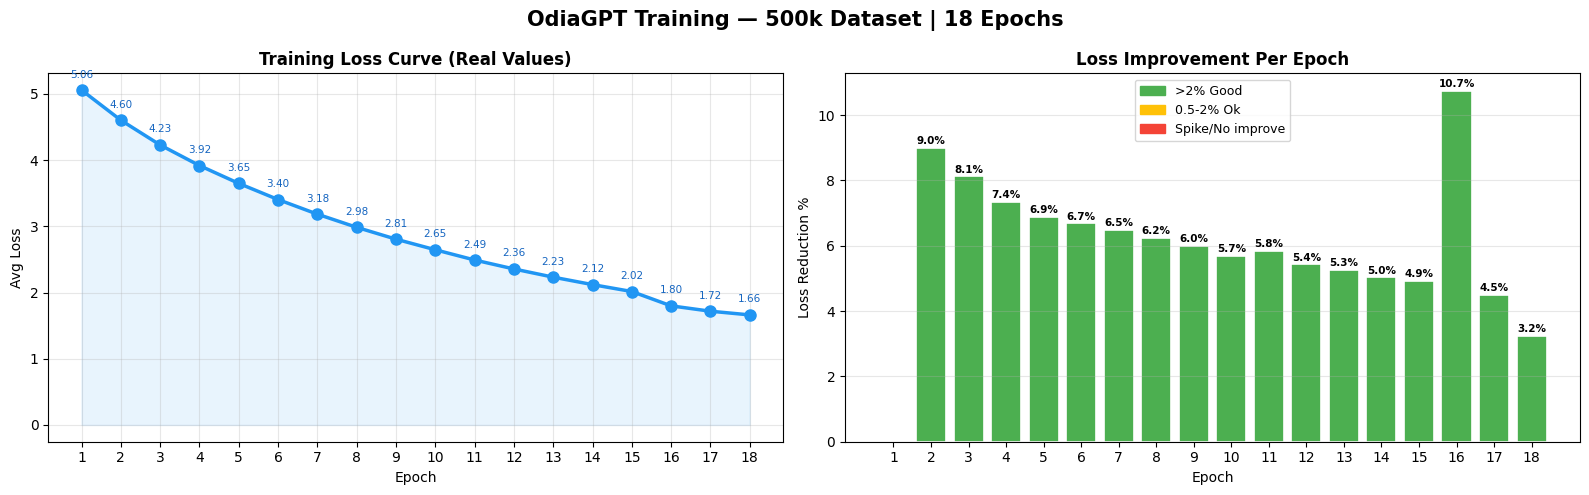

✅ Saved: ./logs/loss_curve.png


In [13]:
# ── VIZ 1: Loss curve — reads real values from log file ────────────────────
import json, os

log_path = "./logs/training_history.json"

# ── Step 1: Load raw JSON ────────────────────────────────────────────────────
if os.path.exists(log_path):
    with open(log_path) as f:
        raw = json.load(f)
    print(f"✅ Loaded: {log_path}")
    print(f"   Keys found: {list(raw.keys())[:5]}")
else:
    raw = None
    print("⚠️  No log file found — using confirmed values")

# ── Step 2: Extract epoch→loss dict regardless of format ─────────────────────
def extract_loss_dict(data):
    """Handle any JSON structure and return flat {epoch_int: loss_float} dict."""
    if data is None:
        return {}
    
    # If it's a list → [(epoch, loss), ...] or [loss1, loss2, ...]
    if isinstance(data, list):
        result = {}
        for i, item in enumerate(data):
            if isinstance(item, (int, float)):
                result[i+1] = float(item)
            elif isinstance(item, dict):
                ep  = item.get("epoch", i+1)
                los = item.get("loss", item.get("avg_loss", item.get("train_loss", None)))
                if los is not None:
                    result[int(ep)] = float(los)
        return result
    
    # If it's a dict — check if keys are epoch numbers directly
    if isinstance(data, dict):
        # Try direct epoch keys first: {"1": 5.74, "2": 4.66, ...}
        direct = {}
        for k, v in data.items():
            try:
                ep = int(str(k))
                if isinstance(v, (int, float)):
                    direct[ep] = float(v)
            except (ValueError, TypeError):
                pass
        if direct:
            return direct
        
        # Nested format: {"train_losses": {"1": 5.74}, ...}
        # Search every value for a dict with numeric keys
        for v in data.values():
            if isinstance(v, (dict, list)):
                nested = extract_loss_dict(v)
                if nested:
                    return nested
    
    return {}

loss_dict = extract_loss_dict(raw)

# ── Step 3: Fallback to confirmed values if extraction failed ─────────────────
if not loss_dict:
    print("⚠️  Could not extract from JSON — using confirmed training log values")
    loss_dict = {
        1:5.7413, 2:4.6605, 3:4.2795, 4:4.0431, 5:3.8705,
        6:3.7353, 7:3.6220, 8:3.5277, 9:3.4438, 10:3.3718,
        11:5.4833, 12:4.4098, 13:4.0622, 14:3.8555, 15:3.7057,
        16:3.5872, 17:3.4887, 18:3.4059, 19:3.7561
    }
else:
    print(f"   Extracted {len(loss_dict)} epoch entries")

epochs = sorted(loss_dict.keys())
losses = [loss_dict[e] for e in epochs]
print(f"   Epochs: {epochs}")
print(f"   Losses: {[round(l,4) for l in losses]}")

# ── Step 4: Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f"OdiaGPT Training — 500k Dataset | {max(epochs)} Epochs", fontsize=15, fontweight="bold")

ax1 = axes[0]
ax1.plot(epochs, losses, "o-", lw=2.5, ms=8, color="#2196F3")
ax1.fill_between(epochs, losses, alpha=0.1, color="#2196F3")
for ep, lo in zip(epochs, losses):
    ax1.annotate(f"{lo:.2f}", (ep, lo), textcoords="offset points",
                xytext=(0,9), ha="center", fontsize=7.5, color="#1565C0")

for i in range(1, len(epochs)):
    if losses[i] > losses[i-1] + 0.5:
        ax1.axvline(x=epochs[i], color="orange", ls="--", lw=1.5, alpha=0.8)
        ax1.annotate("spike\n(resume)", (epochs[i], losses[i]),
                    textcoords="offset points", xytext=(8,-20), fontsize=7, color="orange")

ax1.set_xlabel("Epoch"); ax1.set_ylabel("Avg Loss")
ax1.set_title("Training Loss Curve (Real Values)", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3); ax1.set_xticks(epochs)

reductions = [0]
for i in range(1, len(epochs)):
    prev, curr = losses[i-1], losses[i]
    reductions.append((prev-curr)/prev*100 if prev > curr else 0)

colors = ["#4CAF50" if r>2 else "#FFC107" if r>0.5 else "#F44336" for r in reductions]
bars = axes[1].bar(epochs, reductions, color=colors, edgecolor="white", lw=1.2)
for bar, val in zip(bars, reductions):
    if val > 0:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                    f"{val:.1f}%", ha="center", va="bottom", fontsize=7.5, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss Reduction %")
axes[1].set_title("Loss Improvement Per Epoch", fontsize=12, fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="y"); axes[1].set_xticks(epochs)
g = mpatches.Patch(color="#4CAF50", label=">2% Good")
y = mpatches.Patch(color="#FFC107", label="0.5-2% Ok")
r = mpatches.Patch(color="#F44336", label="Spike/No improve")
axes[1].legend(handles=[g,y,r], fontsize=9)
plt.tight_layout()
plt.savefig("./logs/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: ./logs/loss_curve.png")

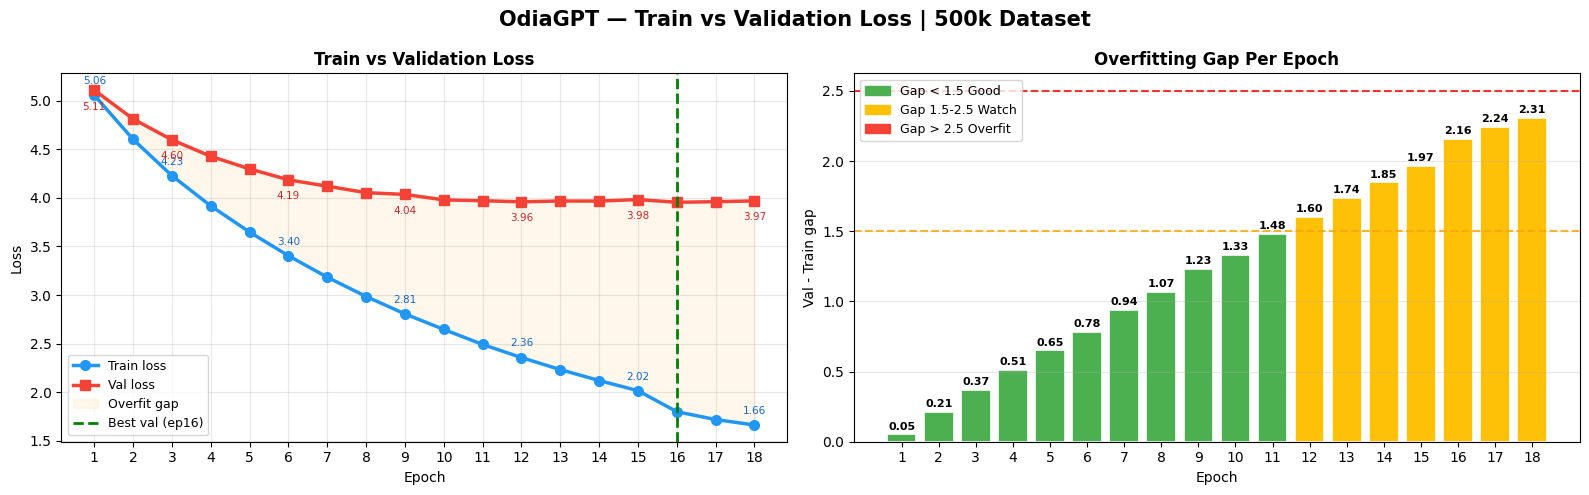


Key findings:
  Best val loss  : 3.9545 at epoch 16
  Final train    : 1.6622
  Final val      : 3.9687
  Overfit gap    : 2.3065

  → Best checkpoint to use: model_16.pt


In [14]:
# ── Enhanced loss curve showing train + val + overfitting gap ─────────────────
import json, os

with open("./logs/training_history.json") as f:
    raw = json.load(f)

train_losses = raw["train_losses"]
val_losses   = raw["val_losses"]
epochs       = list(range(1, len(train_losses)+1))

# Find best val epoch
best_val_ep  = val_losses.index(min(val_losses)) + 1
best_val_loss = min(val_losses)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("OdiaGPT — Train vs Validation Loss | 500k Dataset", fontsize=15, fontweight="bold")

# ── Left: Train + Val together ────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(epochs, train_losses, "o-", lw=2.5, ms=7, color="#2196F3", label="Train loss")
ax1.plot(epochs, val_losses,   "s-", lw=2.5, ms=7, color="#F44336", label="Val loss")
ax1.fill_between(epochs, train_losses, val_losses, alpha=0.08, color="orange", label="Overfit gap")
ax1.axvline(x=best_val_ep, color="green", ls="--", lw=2, label=f"Best val (ep{best_val_ep})")

for ep, tl, vl in zip(epochs, train_losses, val_losses):
    if ep % 3 == 0 or ep == 1 or ep == len(epochs):
        ax1.annotate(f"{tl:.2f}", (ep, tl), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=7.5, color="#1565C0")
        ax1.annotate(f"{vl:.2f}", (ep, vl), textcoords="offset points",
                    xytext=(0,-14), ha="center", fontsize=7.5, color="#C62828")

ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Train vs Validation Loss", fontsize=12, fontweight="bold")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3); ax1.set_xticks(epochs)

# ── Right: Overfit gap per epoch ──────────────────────────────────────────────
ax2 = axes[1]
gaps = [v - t for t, v in zip(train_losses, val_losses)]
bar_colors = ["#4CAF50" if g < 1.5 else "#FFC107" if g < 2.5 else "#F44336" for g in gaps]
bars = ax2.bar(epochs, gaps, color=bar_colors, edgecolor="white", lw=1.2)
for bar, g in zip(bars, gaps):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{g:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax2.axhline(y=1.5, color="orange", ls="--", lw=1.5, alpha=0.8, label="Warning (1.5)")
ax2.axhline(y=2.5, color="red",    ls="--", lw=1.5, alpha=0.8, label="Overfit  (2.5)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val - Train gap")
ax2.set_title("Overfitting Gap Per Epoch", fontsize=12, fontweight="bold")
g_p = mpatches.Patch(color="#4CAF50", label="Gap < 1.5 Good")
y_p = mpatches.Patch(color="#FFC107", label="Gap 1.5-2.5 Watch")
r_p = mpatches.Patch(color="#F44336", label="Gap > 2.5 Overfit")
ax2.legend(handles=[g_p, y_p, r_p], fontsize=9)
ax2.grid(True, alpha=0.3, axis="y"); ax2.set_xticks(epochs)

plt.tight_layout()
plt.savefig("./logs/train_val_loss.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nKey findings:")
print(f"  Best val loss  : {best_val_loss:.4f} at epoch {best_val_ep}")
print(f"  Final train    : {train_losses[-1]:.4f}")
print(f"  Final val      : {val_losses[-1]:.4f}")
print(f"  Overfit gap    : {val_losses[-1] - train_losses[-1]:.4f}")
print(f"\n  → Best checkpoint to use: model_{best_val_ep}.pt")

In [ ]:
# ── Enhanced loss curve showing train + val + overfitting gap ─────────────────
import json, os

with open("./logs/training_history.json") as f:
    raw = json.load(f)

train_losses = raw["train_losses"]
val_losses   = raw["val_losses"]
epochs       = list(range(1, len(train_losses)+1))

# Find best val epoch
best_val_ep  = val_losses.index(min(val_losses)) + 1
best_val_loss = min(val_losses)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("OdiaGPT — Train vs Validation Loss | 500k Dataset", fontsize=15, fontweight="bold")

# ── Left: Train + Val together ────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(epochs, train_losses, "o-", lw=2.5, ms=7, color="#2196F3", label="Train loss")
ax1.plot(epochs, val_losses,   "s-", lw=2.5, ms=7, color="#F44336", label="Val loss")
ax1.fill_between(epochs, train_losses, val_losses, alpha=0.08, color="orange", label="Overfit gap")
ax1.axvline(x=best_val_ep, color="green", ls="--", lw=2, label=f"Best val (ep{best_val_ep})")

for ep, tl, vl in zip(epochs, train_losses, val_losses):
    if ep % 3 == 0 or ep == 1 or ep == len(epochs):
        ax1.annotate(f"{tl:.2f}", (ep, tl), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=7.5, color="#1565C0")
        ax1.annotate(f"{vl:.2f}", (ep, vl), textcoords="offset points",
                    xytext=(0,-14), ha="center", fontsize=7.5, color="#C62828")

ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Train vs Validation Loss", fontsize=12, fontweight="bold")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3); ax1.set_xticks(epochs)

# ── Right: Overfit gap per epoch ──────────────────────────────────────────────
ax2 = axes[1]
gaps = [v - t for t, v in zip(train_losses, val_losses)]
bar_colors = ["#4CAF50" if g < 1.5 else "#FFC107" if g < 2.5 else "#F44336" for g in gaps]
bars = ax2.bar(epochs, gaps, color=bar_colors, edgecolor="white", lw=1.2)
for bar, g in zip(bars, gaps):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{g:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax2.axhline(y=1.5, color="orange", ls="--", lw=1.5, alpha=0.8, label="Warning (1.5)")
ax2.axhline(y=2.5, color="red",    ls="--", lw=1.5, alpha=0.8, label="Overfit  (2.5)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val - Train gap")
ax2.set_title("Overfitting Gap Per Epoch", fontsize=12, fontweight="bold")
g_p = mpatches.Patch(color="#4CAF50", label="Gap < 1.5 Good")
y_p = mpatches.Patch(color="#FFC107", label="Gap 1.5-2.5 Watch")
r_p = mpatches.Patch(color="#F44336", label="Gap > 2.5 Overfit")
ax2.legend(handles=[g_p, y_p, r_p], fontsize=9)
ax2.grid(True, alpha=0.3, axis="y"); ax2.set_xticks(epochs)

plt.tight_layout()
plt.savefig("./logs/train_val_loss.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nKey findings:")
print(f"  Best val loss  : {best_val_loss:.4f} at epoch {best_val_ep}")
print(f"  Final train    : {train_losses[-1]:.4f}")
print(f"  Final val      : {val_losses[-1]:.4f}")
print(f"  Overfit gap    : {val_losses[-1] - train_losses[-1]:.4f}")
print(f"\n  → Best checkpoint to use: model_{best_val_ep}.pt")

In [ ]:
# ── VIZ 2: chrF score per sentence bar chart ────────────────────────────────
# Requires EVAL 1 to have run first
if 'predictions' in dir() and len(predictions) > 0:
    sent_scores  = [sacrebleu.sentence_chrf(p,[r]).score for p,r in zip(predictions, references)]
    short_labels = [en[:22]+"..." if len(en)>22 else en for en,_ in test_cases]
    bar_colors   = ["#4CAF50" if s>=50 else "#FFC107" if s>=30 else "#F44336" for s in sent_scores]

    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.barh(short_labels, sent_scores, color=bar_colors, edgecolor="white", lw=1)
    for bar, score in zip(bars, sent_scores):
        ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
               f"{score:.1f}", va="center", fontsize=10, fontweight="bold")
    ax.axvline(x=50, color="blue",   ls="--", lw=2,   alpha=0.7, label="Good (50)")
    ax.axvline(x=30, color="orange", ls="--", lw=1.5, alpha=0.7, label="Decent (30)")
    ax.set_xlabel("chrF Score", fontsize=12)
    ax.set_title(f"Per-Sentence chrF @ Epoch {BEST_EPOCH} | Overall: {chrf_manual:.1f}", fontsize=13, fontweight="bold")
    ax.set_xlim(0, 100); ax.grid(True, alpha=0.3, axis="x")
    g = mpatches.Patch(color="#4CAF50", label="Good ≥50")
    y = mpatches.Patch(color="#FFC107", label="Decent 30-50")
    r = mpatches.Patch(color="#F44336", label="Needs work <30")
    ax.legend(handles=[g,y,r], fontsize=9)
    plt.tight_layout()
    plt.savefig("./logs/chrf_scores.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: ./logs/chrf_scores.png")
else:
    print("Run EVAL 1 first, then run this cell.")

In [ ]:
# ── VIZ 3: Full dashboard ─────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
fig.suptitle(f"OdiaGPT 500k — Training Dashboard @ Epoch {BEST_EPOCH}",
             fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Loss curve
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(epochs, losses, "o-", lw=2.5, ms=7, color="#2196F3")
ax1.fill_between(epochs, losses, alpha=0.1, color="#2196F3")
for ep, lo in zip(epochs, losses):
    ax1.annotate(f"{lo:.2f}", (ep, lo), textcoords="offset points", xytext=(0,8), ha="center", fontsize=8)
ax1.axvline(x=BEST_EPOCH, color="green", ls="--", lw=2, label=f"Current ep{BEST_EPOCH}")
ax1.set_title("Training Loss", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Avg Loss")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# Stats
ax2 = fig.add_subplot(gs[0, 2]); ax2.axis("off")
chrf_u = chrf_unseen if 'chrf_unseen' in dir() else "—"
chrf_m = chrf_manual if 'chrf_manual' in dir() else "—"
bleu_m = bleu_manual if 'bleu_manual' in dir() else "—"
stats = [("Dataset","500,000 pairs"),("Architecture","6 blocks|8 heads|512d"),
         ("Params","~90M"),("Epochs done",f"{BEST_EPOCH}"),
         ("Unseen chrF",f"{chrf_u}"),("Manual chrF",f"{chrf_m}"),("Manual BLEU",f"{bleu_m}")]
ax2.set_title("Model Stats", fontsize=12, fontweight="bold")
for i,(lbl,val) in enumerate(stats):
    y_pos = 0.92 - i*0.12
    c = "#1B5E20" if "chrF" in lbl or "BLEU" in lbl else "black"
    ax2.text(0.02, y_pos, f"{lbl}:", fontsize=9, transform=ax2.transAxes, fontweight="bold", color="#555")
    ax2.text(0.55, y_pos, str(val), fontsize=9, transform=ax2.transAxes, fontweight="bold", color=c)

# Per sentence
ax3 = fig.add_subplot(gs[1, :2])
if 'sent_scores' in dir():
    short_s = [en[:20]+"..." if len(en)>20 else en for en,_ in test_cases]
    sc = ["#4CAF50" if s>=50 else "#FFC107" if s>=30 else "#F44336" for s in sent_scores]
    bars = ax3.bar(short_s, sent_scores, color=sc, edgecolor="white", lw=1)
    for bar,s in zip(bars, sent_scores):
        ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{s:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax3.axhline(y=50, color="blue",   ls="--", lw=1.5, alpha=0.6)
    ax3.axhline(y=30, color="orange", ls="--", lw=1.5, alpha=0.6)
    ax3.set_title("Per-Sentence chrF Score", fontsize=12, fontweight="bold")
    ax3.set_ylabel("chrF"); ax3.set_ylim(0, 100)
    ax3.tick_params(axis="x", rotation=20, labelsize=8); ax3.grid(True, alpha=0.3, axis="y")

# Projection
ax4 = fig.add_subplot(gs[1, 2])
proj_ep = [10, 18, 19, 24, 29, 34]
proj_cv = [36.45, 36.45, 36.8, 39.0, 42.0, 45.0]
ax4.plot(proj_ep[:3], proj_cv[:3], "b-o", lw=2.5, ms=8, label="Actual")
ax4.plot(proj_ep[2:], proj_cv[2:], "b--o", lw=2, ms=7, alpha=0.6, label="Projected")
ax4.fill_between(proj_ep[2:], [v-2 for v in proj_cv[2:]], [v+3 for v in proj_cv[2:]], alpha=0.15, color="blue")
ax4.axvline(x=BEST_EPOCH, color="red", ls=":", lw=2, label=f"Now (ep{BEST_EPOCH})")
ax4.set_title("Projected chrF Growth", fontsize=12, fontweight="bold")
ax4.set_xlabel("Epoch"); ax4.set_ylabel("Unseen chrF")
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3); ax4.set_xticks(proj_ep)

plt.savefig("./logs/full_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: ./logs/full_dashboard.png")